In [17]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import warnings
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn import preprocessing
import math as mt
from scipy.stats import skew

In [18]:
import networkx as nx
import numpy as np

class Network:
    def __init__(self, name, adjacency_matrix):
        self.name = name
        self.adjacency_matrix = adjacency_matrix
        self.graph = self.create_graph()
        self.real_eigen = None
        self.cluster_coeficient = 0
        self.iso = 0

    def create_graph(self):
        G = nx.DiGraph()  # Instantiate as a directed graph
        for i in range(len(self.adjacency_matrix)):
            for j in range(len(self.adjacency_matrix[i])):
                if self.adjacency_matrix[i][j] != 0:
                    G.add_edge(i, j, weight=self.adjacency_matrix[i][j])
            if all(val == 0 for val in self.adjacency_matrix[i]):
                G.add_node(i)
        return G
    
    def calculate_adjacency_eigenvalues(self):
        eigenvalues = np.linalg.eigvals(self.adjacency_matrix)
        self.real_eigen = np.real(eigenvalues)

    def calculate_isolated_nodes(self):
        isolated_nodes = len([node for node in self.graph.nodes if self.graph.in_degree(node) == 0 and self.graph.out_degree(node) == 0])
        self.iso = isolated_nodes  # Assign the count of isolated nodes to self.iso
    
    def calculate_clustering_coefficient(self):
        self.cluster_coeficient = nx.average_clustering(self.graph)

In [19]:
class Step:
    def __init__(self, step_number):
        self.step_number = step_number
        self.networks = []

    def add_network(self, network):
        self.networks.append(network)


In [20]:
def read_multiple_networks(file_path):
    steps = []
    current_step = None

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if line.startswith("st."):
                if current_step:
                    steps.append(current_step)
                step_number = int(line.split('.')[1])
                current_step = Step(step_number)
            elif line.startswith("Network"):
                network_name = line
                adjacency_matrix = []
            elif line == '---':
                network_instance = Network(network_name, adjacency_matrix)
                current_step.add_network(network_instance)
            else:
                row = [float(value) for value in line.split()]
                adjacency_matrix.append(row)

    if current_step:
        steps.append(current_step)

    return steps
def calculate_cosine_similarity(vectors, steps):
    for step_idx, step in enumerate(steps):
        print(f"Step {step.step_number}:")
        for network_idx, network in enumerate(step.networks):
            print(f"{len(vectors)}")
    similarities = cosine_similarity(vectors)
    return similarities

# Calculate subtraction sum for each step and save them in a single text file
def save_cosine_similarities(file_path, steps, cosine_similarities):
    with open(file_path, 'w') as file:
        for step_idx, step in enumerate(steps):
            file.write(f"Step {step.step_number}\n")
            for i in range(len(step.networks)):
                for j in range(i+1, len(step.networks)):
                    similarity = cosine_similarities[step_idx][i][j]
                    file.write(f"{step.step_number}\t{similarity}\n")
            file.write('\n')
dataset = []

In [24]:
file_path = './Outputs/st2000_nn1000_mu0.010000_refenv0_strt_inpt0.000000/numrun_0/'
address = file_path + 'History.txt'
steps = read_multiple_networks(address)

In [25]:
for step in steps:
    for network in step.networks:
        network.calculate_adjacency_eigenvalues()
        network.calculate_isolated_nodes()
        network.calculate_clustering_coefficient()
        
        

In [27]:
for i in range(len(steps)):

    for j in range(len(steps[i].networks)):
        real_eigen = steps[i].networks[j].iso
        
        if real_eigen != 0 :
            print(i,j)
        

1 5
1 16
1 17
1 49
1 62
1 77
1 102
1 124
1 138
1 160
1 182
1 211
1 219
1 230
1 242
1 270
1 290
1 295
1 312
1 328
1 331
1 351
1 393
1 397
1 407
1 455
1 466
1 470
1 477
1 479
1 481
1 483
1 497
1 504
1 593
1 645
1 658
1 666
1 675
1 716
1 750
1 786
1 809
1 840
1 845
1 846
1 852
1 866
1 871
1 873
1 886
1 887
1 924
1 926
1 935
1 952
1 977


In [30]:
for g in range (6):
    G = str(g)
    file_path = './Outputs/st2000_nn1000_mu0.010000_refenv0_strt_inpt0.000000/numrun_' + G + '/'
    address = file_path + 'History.txt'
    steps = read_multiple_networks(address)
    for step in steps:
        for network in step.networks:
            network.calculate_adjacency_eigenvalues()
            network.calculate_isolated_nodes()
            network.calculate_clustering_coefficient()
            
    for i in range(len(steps)):

        for j in range(len(steps[i].networks)):
            real_eigen = steps[i].networks[j].iso
        
            #if real_eigen != 0 :
                #print(i,j, g, real_eigen)
            if real_eigen == 20 :
                print(i,j, g, real_eigen)
                

In [44]:
saving = file_path + '/Eigen_value.txt'
scenario = ['test']
for g in range (len(scenario)):
    with open(saving, 'w') as file:
        for i in range(len(steps)):
        
            for j in range(len(steps[i].networks)):
                real_eigen = steps[i].networks[j].real_eigen
                for z in real_eigen:
                    if z != 0:
                        z = round(z,4)
                        file.write(f"{i}\t{z}\n")
                        file.flush()
                        dataset.append([scenario[g], i, z, 'single'])

In [26]:
#now doubles:

In [45]:
address = file_path +  'History_du.txt'
steps = read_multiple_networks(address)

for step in steps:
    for network in step.networks:
        network.calculate_adjacency_eigenvalues()


In [46]:
saving = file_path + '/Eigen_valuedu_du.txt'
scenario = ['test']
for g in range (len(scenario)):
    with open(saving, 'w') as file:
        for i in range(len(steps)):
            
            for j in range(len(steps[i].networks)):
                real_eigen = steps[i].networks[j].real_eigen
                for z in real_eigen:
                    if z != 0:
                        z = round(z,4)
                        file.write(f"{i}\t{z}\n")
                        file.flush()
                        dataset.append([scenario[g], i, z, 'double'])

In [48]:
df = pd.DataFrame(dataset, columns=['scenario', 'step', 'Eigen', 'sd'])

<AxesSubplot:xlabel='scenario', ylabel='Eigen'>

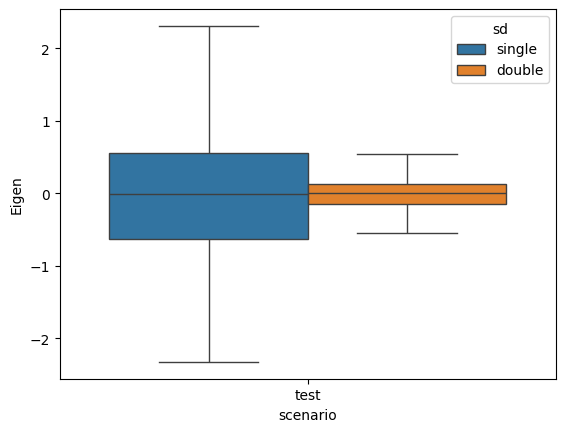

In [53]:
sns.boxplot(df, x='scenario', y='Eigen', hue='sd', showfliers=False)

In [34]:
plt.plot(df[''])

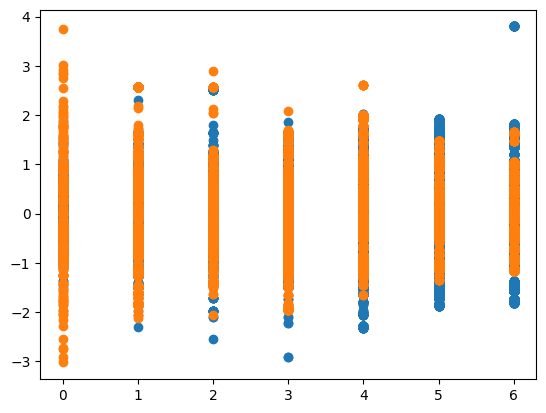

In [36]:
plt.scatter(single_index, single_values)
plt.scatter(double_index, double_values)
plt.show()

array([-0.1079,  0.054 ,  0.054 , ...,  0.    , -0.    ,  0.    ])

In [54]:
df

,scenario,step,Eigen,sd
0,test,0,-0.1079,single
1,test,0,0.0540,single
2,test,0,0.0540,single
3,test,0,-0.2394,single
4,test,0,-0.2394,single
...,...,...,...,...
113724,test,6,-0.0047,double
113725,test,6,0.0000,double
113726,test,6,0.0000,double
113727,test,6,0.0000,double
